# 医学影像智能分析实验（四）

## 基于 U-Net 的甲状腺超声图像分割

| 项目 | 内容 |
|---|---|
| 课程 | 医学影像智能分析 |
| 实验内容 | 医学图像分割 |
| 姓名 |  |
| 学号 |  |
| 日期 |  |

本 Notebook 使用 TN-SCUI2020 灰度超声图像与二值 Mask，完成以下内容：

1. 图像与 Mask 配对检查，以及固定的训练/验证/测试划分；
2. 使用 PyTorch 手写完整 U-Net；
3. 使用 `segmentation_models_pytorch` 建立 ImageNet 预训练 ResNet18 编码器的 U-Net；
4. 在相同数据划分和评价流程下训练、测试两种模型；
5. 报告 Dice、IoU、HD95，绘制训练曲线，并展示成功及失败样本。

对比模型不是只改变一个变量：预训练模型同时具有更深的 ResNet18 编码器、更大的解码器和 ImageNet 初始权重。因此结果解释为“两个完整方案的比较”，不把全部差异都归因于预训练。


In [1]:
from pathlib import Path
import copy
import gc
import os   
import platform
import random
import sys
import time

ROOT = Path('/Users/avery/Documents/Codex/2026-08-26/wo-x')
os.environ.setdefault('HF_HOME', str(ROOT / 'work' / 'hf_cache'))
os.environ.setdefault('TORCH_HOME', str(ROOT / 'work' / 'torch_cache'))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / 'work' / 'matplotlib'))
SMP_RUNTIME = ROOT / 'work' / 'smp_runtime'
if SMP_RUNTIME.exists():
    sys.path.insert(0, str(SMP_RUNTIME))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from PIL import Image, ImageOps
from scipy.ndimage import binary_erosion, distance_transform_edt
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF
import segmentation_models_pytorch as smp

SEED = 42
IMAGE_SIZE = 256
MAX_EPOCHS = 24
EARLY_STOPPING_PATIENCE = 7
HAND_BASE_CHANNELS = 16
REUSE_EXISTING_CHECKPOINTS = True  # 直接加载已保存的最佳模型，避免重新训练
HAND_LEARNING_RATE = 3e-4
PRETRAINED_ENCODER_LR = 1e-4
PRETRAINED_DECODER_LR = 3e-4
WEIGHT_DECAY = 1e-4
THRESHOLD = 0.5

DATA_ROOT = Path('/Users/avery/Desktop/图像分割/TNSCUI2020_train')
OUTPUT_DIR = ROOT / 'outputs' / 'model_compare_artifacts'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROGRESS_LOG = OUTPUT_DIR / 'training_progress.log'

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

BATCH_SIZE = 8 if device.type in {'mps', 'cuda'} else 4
NUM_WORKERS = 0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('python:', platform.python_version())
print('torch / SMP:', torch.__version__, smp.__version__)
print('device:', device)
print('image size / batch:', IMAGE_SIZE, BATCH_SIZE)


python: 3.13.9
torch / SMP: 2.13.0 0.5.0
device: mps
image size / batch: 256 8


## 一、数据检查与固定划分

原始图像与 Mask 使用相同文件名配对。`CATE` 是图像级类别标签，本实验只用它进行分层划分；像素级分割标签来自 `mask/` 文件夹。


In [2]:
csv_path = DATA_ROOT / 'train.csv'
image_dir = DATA_ROOT / 'image'
mask_dir = DATA_ROOT / 'mask'

df = pd.read_csv(csv_path)
df.columns = [column.strip() for column in df.columns]
df['ID'] = df['ID'].astype(str).str.strip()
df['image_path'] = df['ID'].map(lambda name: image_dir / name)
df['mask_path'] = df['ID'].map(lambda name: mask_dir / name)

missing_images = df.loc[~df.image_path.map(Path.exists), 'ID'].tolist()
missing_masks = df.loc[~df.mask_path.map(Path.exists), 'ID'].tolist()
assert not missing_images, f'缺失原图: {missing_images[:5]}'
assert not missing_masks, f'缺失 Mask: {missing_masks[:5]}'
assert df.ID.is_unique, 'ID 存在重复'

train_df, temporary_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['CATE']
)
val_df, test_df = train_test_split(
    temporary_df, test_size=0.50, random_state=SEED,
    stratify=temporary_df['CATE']
)

split_df = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='validation'),
    test_df.assign(split='test'),
]).sort_values(['split', 'ID'])
split_df[['ID', 'CATE', 'split']].to_csv(
    OUTPUT_DIR / 'data_split.csv', index=False, encoding='utf-8-sig'
)

print('paired samples:', len(df))
print('train / validation / test:', len(train_df), len(val_df), len(test_df))
display(pd.crosstab(split_df['split'], split_df['CATE'], margins=True))


paired samples: 3644
train / validation / test: 2550 547 547


CATE,0,1,All
split,,,
test,247,300,547
train,1148,1402,2550
validation,246,301,547
All,1641,2003,3644


## 二、Dataset 与数据增强

每对原图和 Mask 先等比例缩放，再补黑边到 256×256。原图使用双线性插值，Mask 使用最近邻插值。训练集进行轻微旋转、平移、缩放、水平翻转以及原图亮度/对比度增强；所有几何变换对图像和 Mask 同步执行。


image batch: (8, 1, 256, 256) range: (0.0, 1.0)
mask batch: (8, 1, 256, 256) values: [0.0, 1.0]


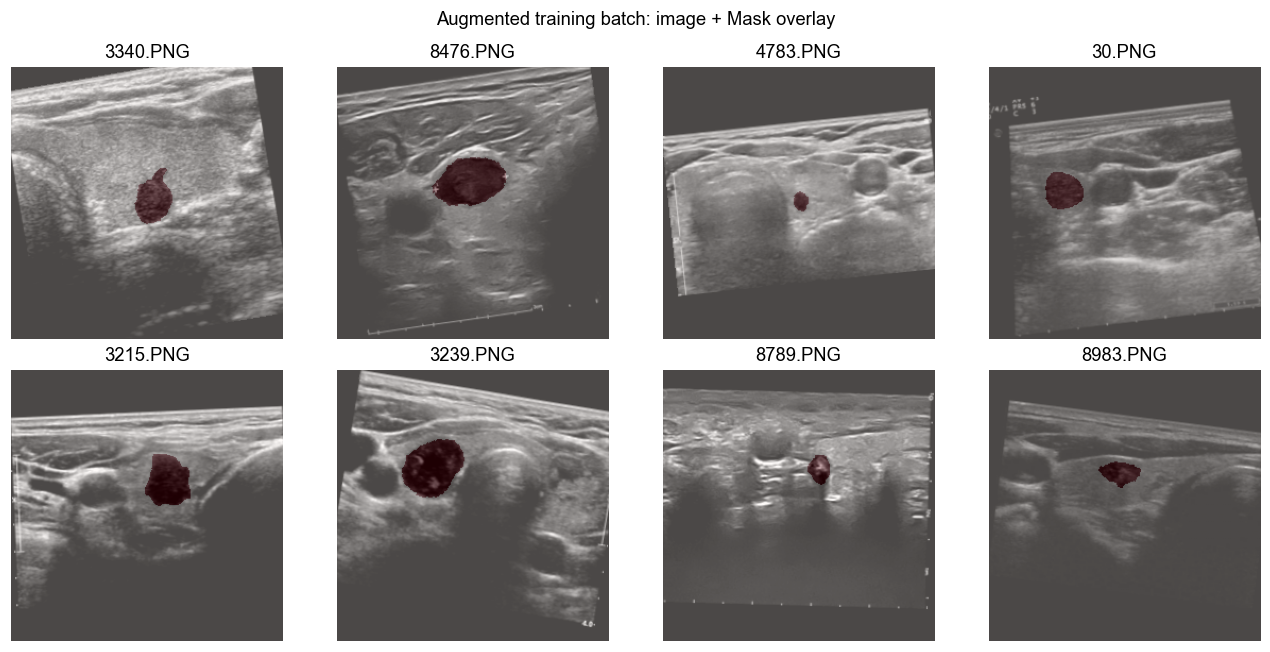

In [3]:
def resize_and_pad(image, mask, size=IMAGE_SIZE):
    image = image.convert('L')
    mask = mask.convert('L')
    scale = min(size / image.width, size / image.height)
    new_width = max(1, round(image.width * scale))
    new_height = max(1, round(image.height * scale))
    image = image.resize((new_width, new_height), Image.Resampling.BILINEAR)
    mask = mask.resize((new_width, new_height), Image.Resampling.NEAREST)

    left = (size - new_width) // 2
    top = (size - new_height) // 2
    border = (left, top, size - new_width - left, size - new_height - top)
    image = ImageOps.expand(image, border=border, fill=0)
    mask = ImageOps.expand(mask, border=border, fill=0)
    return image, mask


class TNSCUISegmentationDataset(Dataset):
    def __init__(self, frame, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row.image_path) as image, Image.open(row.mask_path) as mask:
            image, mask = resize_and_pad(image, mask)

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            angle = random.uniform(-10, 10)
            translation = (random.randint(-8, 8), random.randint(-8, 8))
            scale = random.uniform(0.95, 1.05)
            image = TF.affine(
                image, angle=angle, translate=translation, scale=scale,
                shear=[0.0, 0.0], interpolation=InterpolationMode.BILINEAR, fill=0,
            )
            mask = TF.affine(
                mask, angle=angle, translate=translation, scale=scale,
                shear=[0.0, 0.0], interpolation=InterpolationMode.NEAREST, fill=0,
            )
            image = TF.adjust_brightness(image, random.uniform(0.90, 1.10))
            image = TF.adjust_contrast(image, random.uniform(0.90, 1.10))

        image_array = np.asarray(image, dtype=np.float32) / 255.0
        mask_array = (np.asarray(mask, dtype=np.uint8) > 0).astype(np.float32)
        return (
            torch.from_numpy(image_array).unsqueeze(0),
            torch.from_numpy(mask_array).unsqueeze(0),
            row.ID,
        )


train_loader = DataLoader(
    TNSCUISegmentationDataset(train_df, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    TNSCUISegmentationDataset(val_df), batch_size=BATCH_SIZE,
    shuffle=False, num_workers=NUM_WORKERS,
)
test_dataset = TNSCUISegmentationDataset(test_df)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
)

images, masks, sample_ids = next(iter(train_loader))
print('image batch:', tuple(images.shape), 'range:', (images.min().item(), images.max().item()))
print('mask batch:', tuple(masks.shape), 'values:', torch.unique(masks).tolist())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for axis, image, mask, sample_id in zip(axes.flat, images[:8], masks[:8], sample_ids[:8]):
    axis.imshow(image[0], cmap='gray', vmin=0, vmax=1)
    axis.imshow(mask[0], cmap='Reds', alpha=0.30)
    axis.set_title(sample_id)
    axis.axis('off')
fig.suptitle('Augmented training batch: image + Mask overlay')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'augmented_batch.png', dpi=160, bbox_inches='tight')
plt.show()


## 三、两个对比模型

手写 U-Net 使用四级编码器、四级解码器和跳跃连接。预训练方案使用 SMP U-Net、ResNet18 编码器和 ImageNet 权重。灰度图在预训练模型内部复制为三个相同通道，并按 ImageNet 均值和标准差归一化，从而保留预训练输入约定。


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class HandWrittenUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=HAND_BASE_CHANNELS):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.output = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        x = (x - 0.5) / 0.5
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        x = self.bottleneck(self.pool(s4))
        x = self.dec4(torch.cat([self.up4(x), s4], dim=1))
        x = self.dec3(torch.cat([self.up3(x), s3], dim=1))
        x = self.dec2(torch.cat([self.up2(x), s2], dim=1))
        x = self.dec1(torch.cat([self.up1(x), s1], dim=1))
        return self.output(x)


class PretrainedResNet18UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = smp.Unet(
            encoder_name='resnet18',
            encoder_weights='imagenet',
            in_channels=3,
            classes=1,
            activation=None,
        )
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = x.repeat(1, 3, 1, 1)
        x = (x - self.mean) / self.std
        return self.network(x)


def parameter_count(model):
    return sum(parameter.numel() for parameter in model.parameters())


hand_demo = HandWrittenUNet()
pretrained_demo = PretrainedResNet18UNet()
model_info = pd.DataFrame([
    {'model': 'Hand-written U-Net', 'parameters': parameter_count(hand_demo),
     'encoder': '4-level custom encoder', 'pretrained': False},
    {'model': 'ResNet18 pretrained U-Net', 'parameters': parameter_count(pretrained_demo),
     'encoder': 'ResNet18', 'pretrained': True},
])
display(model_info)
with torch.no_grad():
    example = torch.zeros(2, 1, IMAGE_SIZE, IMAGE_SIZE)
    print('hand output:', tuple(hand_demo(example).shape))
    print('pretrained output:', tuple(pretrained_demo(example).shape))
del hand_demo, pretrained_demo, example
gc.collect()


,model,parameters,encoder,pretrained
0,Hand-written U-Net,1942289,4-level custom encoder,False
1,ResNet18 pretrained U-Net,14328209,ResNet18,True


hand output: (2, 1, 256, 256)
pretrained output: (2, 1, 256, 256)


20

## 四、损失函数与评价指标

训练损失为 `0.3 × BCEWithLogitsLoss + 0.7 × Soft Dice Loss`。测试统一使用阈值 0.5，报告逐图平均 Dice、IoU 和 HD95。HD95 以预处理后的像素为单位，越小越好。


In [5]:
bce_loss = nn.BCEWithLogitsLoss()


def soft_dice_loss(logits, targets, smooth=1.0):
    probabilities = torch.sigmoid(logits)
    dimensions = (1, 2, 3)
    intersection = (probabilities * targets).sum(dimensions)
    denominator = probabilities.sum(dimensions) + targets.sum(dimensions)
    dice = (2 * intersection + smooth) / (denominator + smooth)
    return 1 - dice.mean()


def segmentation_loss(logits, targets):
    return 0.3 * bce_loss(logits, targets) + 0.7 * soft_dice_loss(logits, targets)


def dice_iou_per_image(logits, targets, threshold=THRESHOLD, eps=1e-7):
    predictions = torch.sigmoid(logits) >= threshold
    targets_bool = targets >= 0.5
    dimensions = (1, 2, 3)
    intersection = (predictions & targets_bool).sum(dimensions).float()
    pred_sum = predictions.sum(dimensions).float()
    target_sum = targets_bool.sum(dimensions).float()
    dice = (2 * intersection + eps) / (pred_sum + target_sum + eps)
    union = pred_sum + target_sum - intersection
    iou = (intersection + eps) / (union + eps)
    return dice, iou


def hd95_binary(prediction, target):
    prediction = prediction.astype(bool)
    target = target.astype(bool)
    if not prediction.any() and not target.any():
        return 0.0
    if not prediction.any() or not target.any():
        return float(np.hypot(*prediction.shape))

    pred_border = prediction ^ binary_erosion(prediction)
    target_border = target ^ binary_erosion(target)
    target_distance = distance_transform_edt(~target_border)
    pred_distance = distance_transform_edt(~pred_border)
    distances = np.concatenate([
        target_distance[pred_border],
        pred_distance[target_border],
    ])
    return float(np.percentile(distances, 95))


## 五、训练两个模型

两模型使用相同数据划分、数据增强、损失函数、最大训练轮数和早停规则。预训练模型采用较低编码器学习率，避免快速破坏 ImageNet 特征；其解码器学习率与手写模型一致。每轮打印训练/验证指标、学习率和耗时，并保存验证 Dice 最好的权重。


In [6]:
def clear_device_cache():
    gc.collect()
    if device.type == 'mps':
        torch.mps.empty_cache()
    elif device.type == 'cuda':
        torch.cuda.empty_cache()


def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train(training)
    loss_sum = 0.0
    dice_values, iou_values = [], []
    context = torch.enable_grad() if training else torch.no_grad()

    with context:
        for images, masks, _ in loader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = segmentation_loss(logits, masks)
            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            batch_dice, batch_iou = dice_iou_per_image(logits.detach(), masks)
            loss_sum += loss.item() * len(images)
            dice_values.extend(batch_dice.cpu().tolist())
            iou_values.extend(batch_iou.cpu().tolist())

    return {
        'loss': loss_sum / len(loader.dataset),
        'dice': float(np.mean(dice_values)),
        'iou': float(np.mean(iou_values)),
    }


def make_optimizer(model, model_key):
    if model_key == 'pretrained_resnet18_unet':
        return torch.optim.AdamW([
            {'params': model.network.encoder.parameters(), 'lr': PRETRAINED_ENCODER_LR},
            {'params': model.network.decoder.parameters(), 'lr': PRETRAINED_DECODER_LR},
            {'params': model.network.segmentation_head.parameters(), 'lr': PRETRAINED_DECODER_LR},
        ], weight_decay=WEIGHT_DECAY)
    return torch.optim.AdamW(
        model.parameters(), lr=HAND_LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )


def train_model(model, model_key, display_name):
    checkpoint_path = OUTPUT_DIR / f'{model_key}_best.pt'
    history_path = OUTPUT_DIR / f'{model_key}_history.csv'

    if REUSE_EXISTING_CHECKPOINTS and checkpoint_path.exists() and history_path.exists():
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f'[{display_name}] loaded existing best checkpoint')
        return model.to(device), pd.read_csv(history_path), checkpoint

    model = model.to(device)
    optimizer = make_optimizer(model, model_key)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )
    history = []
    best_dice = -1.0
    best_epoch = 0
    stale_epochs = 0
    training_start = time.time()

    with PROGRESS_LOG.open('a', encoding='utf-8') as log:
        log.write(f'\nSTART {display_name}\n')
        log.flush()

        for epoch in range(1, MAX_EPOCHS + 1):
            epoch_start = time.time()
            train_metrics = run_epoch(model, train_loader, optimizer)
            val_metrics = run_epoch(model, val_loader)
            scheduler.step(val_metrics['loss'])
            elapsed = time.time() - epoch_start
            learning_rates = sorted({group['lr'] for group in optimizer.param_groups})
            row = {
                'epoch': epoch,
                'train_loss': train_metrics['loss'],
                'val_loss': val_metrics['loss'],
                'train_dice': train_metrics['dice'],
                'val_dice': val_metrics['dice'],
                'val_iou': val_metrics['iou'],
                'learning_rates': '/'.join(f'{lr:.2e}' for lr in learning_rates),
                'seconds': elapsed,
            }
            history.append(row)
            message = (
                f'[{display_name}] epoch {epoch:02d}/{MAX_EPOCHS} | '
                f'train loss {train_metrics["loss"]:.4f} dice {train_metrics["dice"]:.4f} | '
                f'val loss {val_metrics["loss"]:.4f} dice {val_metrics["dice"]:.4f} '
                f'iou {val_metrics["iou"]:.4f} | lr {row["learning_rates"]} | {elapsed:.1f}s'
            )
            print(message, flush=True)
            log.write(message + '\n')
            log.flush()

            if val_metrics['dice'] > best_dice + 1e-4:
                best_dice = val_metrics['dice']
                best_epoch = epoch
                stale_epochs = 0
                torch.save({
                    'model_state_dict': {key: value.detach().cpu() for key, value in model.state_dict().items()},
                    'model_key': model_key,
                    'best_validation_dice': best_dice,
                    'best_epoch': best_epoch,
                    'image_size': IMAGE_SIZE,
                    'threshold': THRESHOLD,
                    'training_minutes': (time.time() - training_start) / 60,
                }, checkpoint_path)
            else:
                stale_epochs += 1

            pd.DataFrame(history).to_csv(history_path, index=False, encoding='utf-8-sig')
            if stale_epochs >= EARLY_STOPPING_PATIENCE:
                stop_message = f'[{display_name}] early stopping at epoch {epoch}; best epoch = {best_epoch}'
                print(stop_message, flush=True)
                log.write(stop_message + '\n')
                log.flush()
                break

    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    model.load_state_dict(checkpoint['model_state_dict'])
    return model.to(device), pd.DataFrame(history), checkpoint


PROGRESS_LOG.write_text('Two-model training progress\n', encoding='utf-8')

hand_model, hand_history, hand_checkpoint = train_model(
    HandWrittenUNet(), 'hand_unet', 'Hand-written U-Net'
)
hand_model = hand_model.cpu()
clear_device_cache()

pretrained_model, pretrained_history, pretrained_checkpoint = train_model(
    PretrainedResNet18UNet(), 'pretrained_resnet18_unet', 'ResNet18 pretrained U-Net'
)
pretrained_model = pretrained_model.cpu()
clear_device_cache()

print('best epochs:', hand_checkpoint['best_epoch'], pretrained_checkpoint['best_epoch'])


[Hand-written U-Net] loaded existing best checkpoint
[ResNet18 pretrained U-Net] loaded existing best checkpoint
best epochs: 24 24


## 六、训练曲线与测试集比较


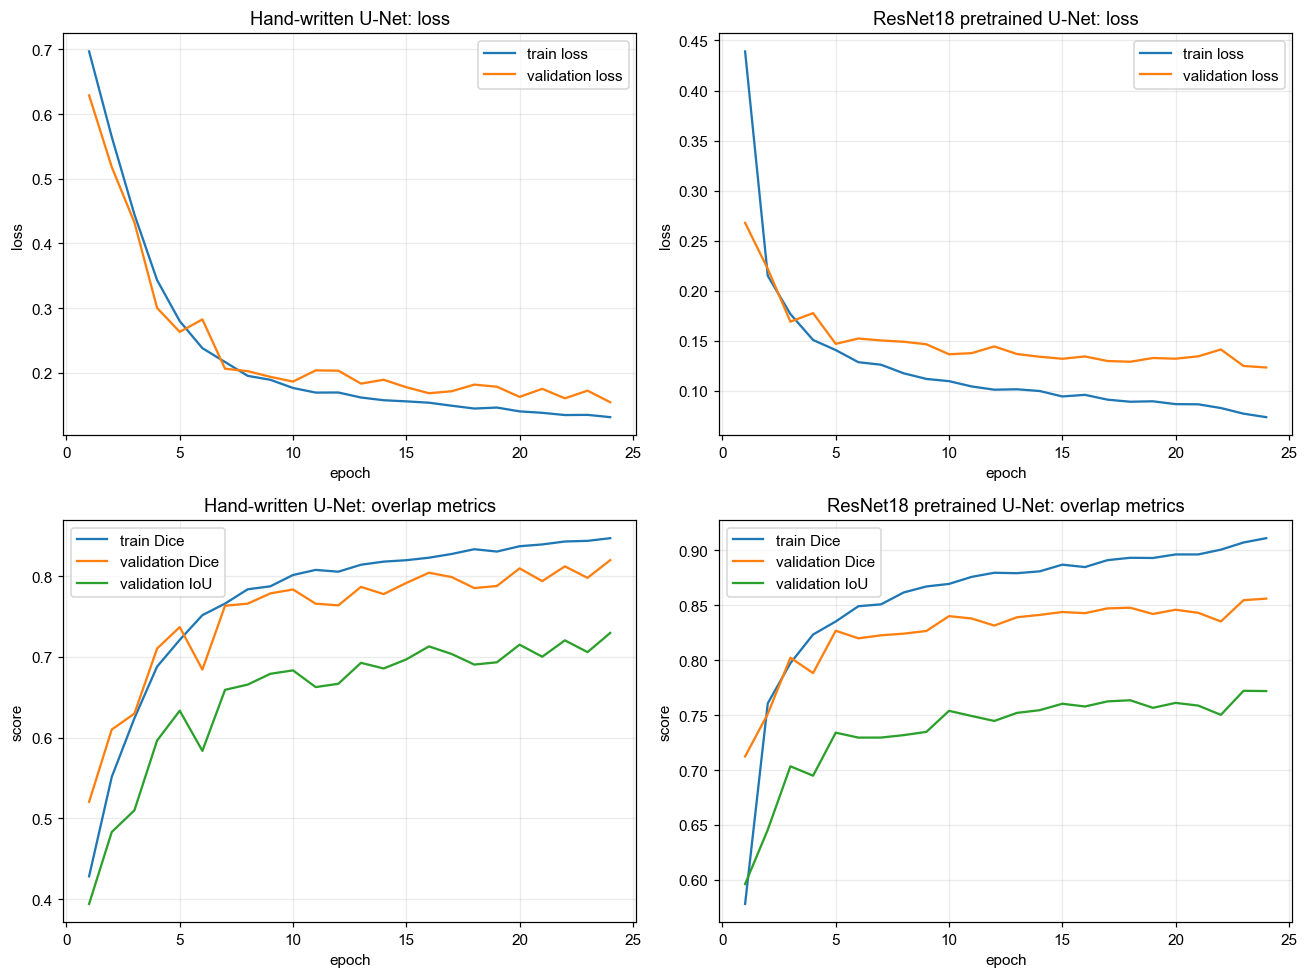

,model,parameters,best_epoch,validation_dice,test_dice_mean,test_iou_mean,test_hd95_mean_pixels,test_hd95_median_pixels
0,Hand-written U-Net,1942289,24,0.8196,0.8167,0.7281,21.05,8.00
1,ResNet18 pretrained U-Net,14328209,24,0.8560,0.8512,0.7711,12.27,6.00


In [7]:
histories = {
    'Hand-written U-Net': hand_history,
    'ResNet18 pretrained U-Net': pretrained_history,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for column, (name, history) in enumerate(histories.items()):
    axes[0, column].plot(history.epoch, history.train_loss, label='train loss')
    axes[0, column].plot(history.epoch, history.val_loss, label='validation loss')
    axes[0, column].set(title=f'{name}: loss', xlabel='epoch', ylabel='loss')
    axes[0, column].legend()
    axes[0, column].grid(alpha=0.25)

    axes[1, column].plot(history.epoch, history.train_dice, label='train Dice')
    axes[1, column].plot(history.epoch, history.val_dice, label='validation Dice')
    axes[1, column].plot(history.epoch, history.val_iou, label='validation IoU')
    axes[1, column].set(title=f'{name}: overlap metrics', xlabel='epoch', ylabel='score')
    axes[1, column].legend()
    axes[1, column].grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()


def predict_probabilities(model, loader):
    model = model.to(device)
    model.eval()
    probabilities, targets, ids, images_all = [], [], [], []
    with torch.no_grad():
        for images, masks, sample_ids in loader:
            logits = model(images.to(device, non_blocking=True))
            probabilities.append(torch.sigmoid(logits).cpu())
            targets.append(masks.cpu())
            images_all.append(images.cpu())
            ids.extend(sample_ids)
    model = model.cpu()
    clear_device_cache()
    return (
        torch.cat(probabilities), torch.cat(targets), ids, torch.cat(images_all)
    )


hand_probabilities, test_targets, test_ids, test_images = predict_probabilities(hand_model, test_loader)
pretrained_probabilities, targets_check, ids_check, images_check = predict_probabilities(pretrained_model, test_loader)
assert test_ids == ids_check
assert torch.equal(test_targets, targets_check)


def case_metrics(probabilities, targets, ids, model_name):
    predictions = probabilities >= THRESHOLD
    target_bool = targets >= 0.5
    rows = []
    for index, sample_id in enumerate(ids):
        pred = predictions[index, 0].numpy()
        target = target_bool[index, 0].numpy()
        intersection = np.logical_and(pred, target).sum()
        pred_sum = pred.sum()
        target_sum = target.sum()
        union = np.logical_or(pred, target).sum()
        rows.append({
            'ID': sample_id,
            'model': model_name,
            'dice': float((2 * intersection + 1e-7) / (pred_sum + target_sum + 1e-7)),
            'iou': float((intersection + 1e-7) / (union + 1e-7)),
            'hd95_pixels': hd95_binary(pred, target),
            'predicted_pixels': int(pred_sum),
            'target_pixels': int(target_sum),
        })
    return pd.DataFrame(rows)


hand_cases = case_metrics(hand_probabilities, test_targets, test_ids, 'Hand-written U-Net')
pretrained_cases = case_metrics(
    pretrained_probabilities, test_targets, test_ids, 'ResNet18 pretrained U-Net'
)
all_cases = pd.concat([hand_cases, pretrained_cases], ignore_index=True)
all_cases.to_csv(OUTPUT_DIR / 'test_case_metrics.csv', index=False, encoding='utf-8-sig')

comparison = pd.DataFrame([
    {
        'model': 'Hand-written U-Net',
        'parameters': parameter_count(hand_model),
        'best_epoch': hand_checkpoint['best_epoch'],
        'validation_dice': hand_checkpoint['best_validation_dice'],
        'test_dice_mean': hand_cases.dice.mean(),
        'test_iou_mean': hand_cases.iou.mean(),
        'test_hd95_mean_pixels': hand_cases.hd95_pixels.mean(),
        'test_hd95_median_pixels': hand_cases.hd95_pixels.median(),
    },
    {
        'model': 'ResNet18 pretrained U-Net',
        'parameters': parameter_count(pretrained_model),
        'best_epoch': pretrained_checkpoint['best_epoch'],
        'validation_dice': pretrained_checkpoint['best_validation_dice'],
        'test_dice_mean': pretrained_cases.dice.mean(),
        'test_iou_mean': pretrained_cases.iou.mean(),
        'test_hd95_mean_pixels': pretrained_cases.hd95_pixels.mean(),
        'test_hd95_median_pixels': pretrained_cases.hd95_pixels.median(),
    },
])
comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False, encoding='utf-8-sig')
display(comparison.style.format({
    'validation_dice': '{:.4f}', 'test_dice_mean': '{:.4f}',
    'test_iou_mean': '{:.4f}', 'test_hd95_mean_pixels': '{:.2f}',
    'test_hd95_median_pixels': '{:.2f}',
}))


## 七、分割结果与失败案例

下面展示测试集中一个较好样本、一个中等样本和一个失败样本。绿色轮廓是真实边界，红色轮廓是预测边界。


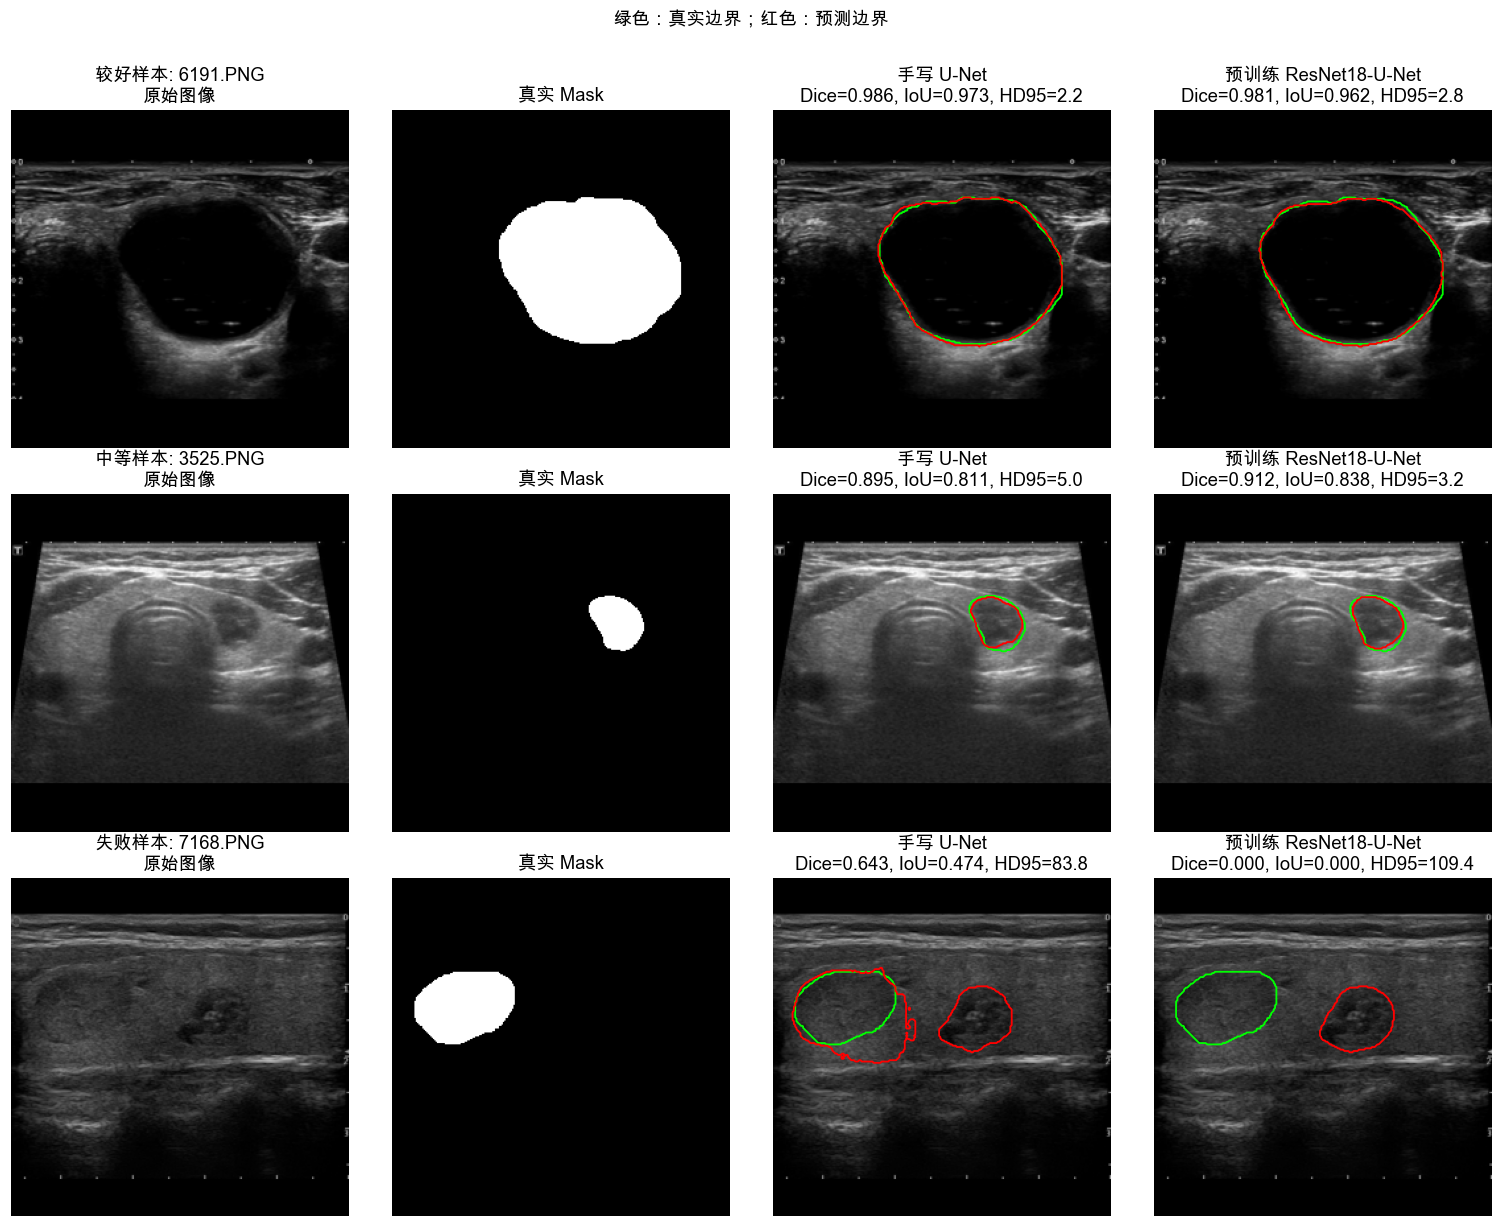

,ID,model,dice,iou,hd95_pixels,predicted_pixels,target_pixels,analysis
186,7168.PNG,Hand-written U-Net,6.427510e-01,4.735689e-01,83.833746,6824,3267,该样本在当前最佳方案下 Dice 最低。应结合叠加图判断是漏分割、过分割、远处伪小块还是边界...
733,7168.PNG,ResNet18 pretrained U-Net,1.882530e-11,1.882530e-11,109.395609,2045,3267,该样本在当前最佳方案下 Dice 最低。应结合叠加图判断是漏分割、过分割、远处伪小块还是边界...


In [8]:
best_model_name = comparison.sort_values('test_dice_mean', ascending=False).iloc[0].model
selector_cases = pretrained_cases if best_model_name == 'ResNet18 pretrained U-Net' else hand_cases
ordered = selector_cases.sort_values('dice').reset_index(drop=True)
selected_ids = [ordered.iloc[-1].ID, ordered.iloc[len(ordered) // 2].ID, ordered.iloc[0].ID]
row_titles = ['较好样本', '中等样本', '失败样本']
id_to_index = {sample_id: index for index, sample_id in enumerate(test_ids)}

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for row, (sample_id, row_title) in enumerate(zip(selected_ids, row_titles)):
    index = id_to_index[sample_id]
    image = test_images[index, 0].numpy()
    target = test_targets[index, 0].numpy() >= 0.5
    hand_pred = hand_probabilities[index, 0].numpy() >= THRESHOLD
    pretrained_pred = pretrained_probabilities[index, 0].numpy() >= THRESHOLD

    axes[row, 0].imshow(image, cmap='gray', vmin=0, vmax=1)
    axes[row, 0].set_title(f'{row_title}: {sample_id}\n原始图像')
    axes[row, 1].imshow(target, cmap='gray', vmin=0, vmax=1)
    axes[row, 1].set_title('真实 Mask')

    for column, (prediction, cases, title) in enumerate([
        (hand_pred, hand_cases, '手写 U-Net'),
        (pretrained_pred, pretrained_cases, '预训练 ResNet18-U-Net'),
    ], start=2):
        score = cases.loc[cases.ID == sample_id].iloc[0]
        axes[row, column].imshow(image, cmap='gray', vmin=0, vmax=1)
        axes[row, column].contour(target.astype(float), levels=[0.5], colors='lime', linewidths=1.2)
        if prediction.any():
            axes[row, column].contour(prediction.astype(float), levels=[0.5], colors='red', linewidths=1.2)
        axes[row, column].set_title(
            f'{title}\nDice={score.dice:.3f}, IoU={score.iou:.3f}, HD95={score.hd95_pixels:.1f}'
        )

    for axis in axes[row]:
        axis.axis('off')

fig.suptitle('绿色：真实边界；红色：预测边界', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'segmentation_comparison_examples.png', dpi=180, bbox_inches='tight')
plt.show()

failure_id = selected_ids[-1]
failure_rows = all_cases.loc[all_cases.ID == failure_id].copy()
failure_rows['analysis'] = (
    '该样本在当前最佳方案下 Dice 最低。应结合叠加图判断是漏分割、过分割、'
    '远处伪小块还是边界偏差；潜在原因包括目标较小、边界模糊、低对比度以及缩放后的细节损失。'
)
failure_rows.to_csv(OUTPUT_DIR / 'failure_analysis.csv', index=False, encoding='utf-8-sig')
display(failure_rows)


## 八、实验小结

1. **实验任务与数据处理**：本实验在 TN-SCUI2020 的 3644 对甲状腺超声图像和二值 Mask 上完成结节分割。数据按 CATE 分层划分为训练集 2550 张、验证集 547 张和测试集 547 张。图像与 Mask 等比例缩放并补黑边到 256×256；仅训练集采用同步的几何增强，以及原图亮度和对比度增强。

2. **对比设置**：手写 U-Net 从随机参数开始训练，共 1,942,289 个参数；对比模型使用 ImageNet 预训练 ResNet18 编码器和 SMP U-Net 解码器，共 14,328,209 个参数，约为手写模型的 7.38 倍。两个模型使用相同的数据划分、0.3×BCE+0.7×Soft Dice 组合损失和 0.5 推理阈值，并分别选取验证 Dice 最高的权重进行最终测试。

3. **定量结果**：手写 U-Net 的最佳轮数为第 24 轮，验证 Dice=0.8196；测试 Dice=0.8167、IoU=0.7281，平均/中位 HD95=21.05/8.00 像素。预训练 ResNet18 U-Net 的最佳轮数同为第 24 轮，验证 Dice=0.8560；测试 Dice=0.8512、IoU=0.7711，平均/中位 HD95=12.27/6.00 像素。

4. **模型比较**：以“预训练模型减去手写模型”计算，测试 Dice 差值为 +0.0345，IoU 差值为 +0.0431，平均 HD95 差值为 -8.78 像素（Dice/IoU 越大越好，HD95 越小越好）。因此，在本次固定划分和统一评价流程下，预训练 ResNet18 U-Net 的总体表现更好；同时还应结合参数量和计算开销评价模型。

5. **可视化与失败案例**：测试样本的绿色轮廓表示真实边界，红色轮廓表示预测边界。当前最佳方案中 Dice 最低的样本为 7168.PNG。失败可能表现为漏分割、过分割、远处伪小块或边界偏移，潜在原因包括超声散斑噪声、结节边界模糊、目标较小、图像对比度低，以及缩放后细节减少。

6. **结论与局限**：本实验中，预训练 ResNet18 U-Net 在当前设置下总体更优。不过，两种方案不仅预训练状态不同，编码器结构、解码器规模和参数量也不同，因此本实验比较的是两个完整方案，不能把全部差异单独归因于预训练。此外，本结果来自一次固定的数据划分和内部测试集，尚未通过多次随机实验、五折交叉验证或官方隐藏测试集验证。后续可在保持相同架构的前提下比较随机初始化与预训练初始化，并尝试更高输入分辨率、多次重复实验和针对边界的损失函数。


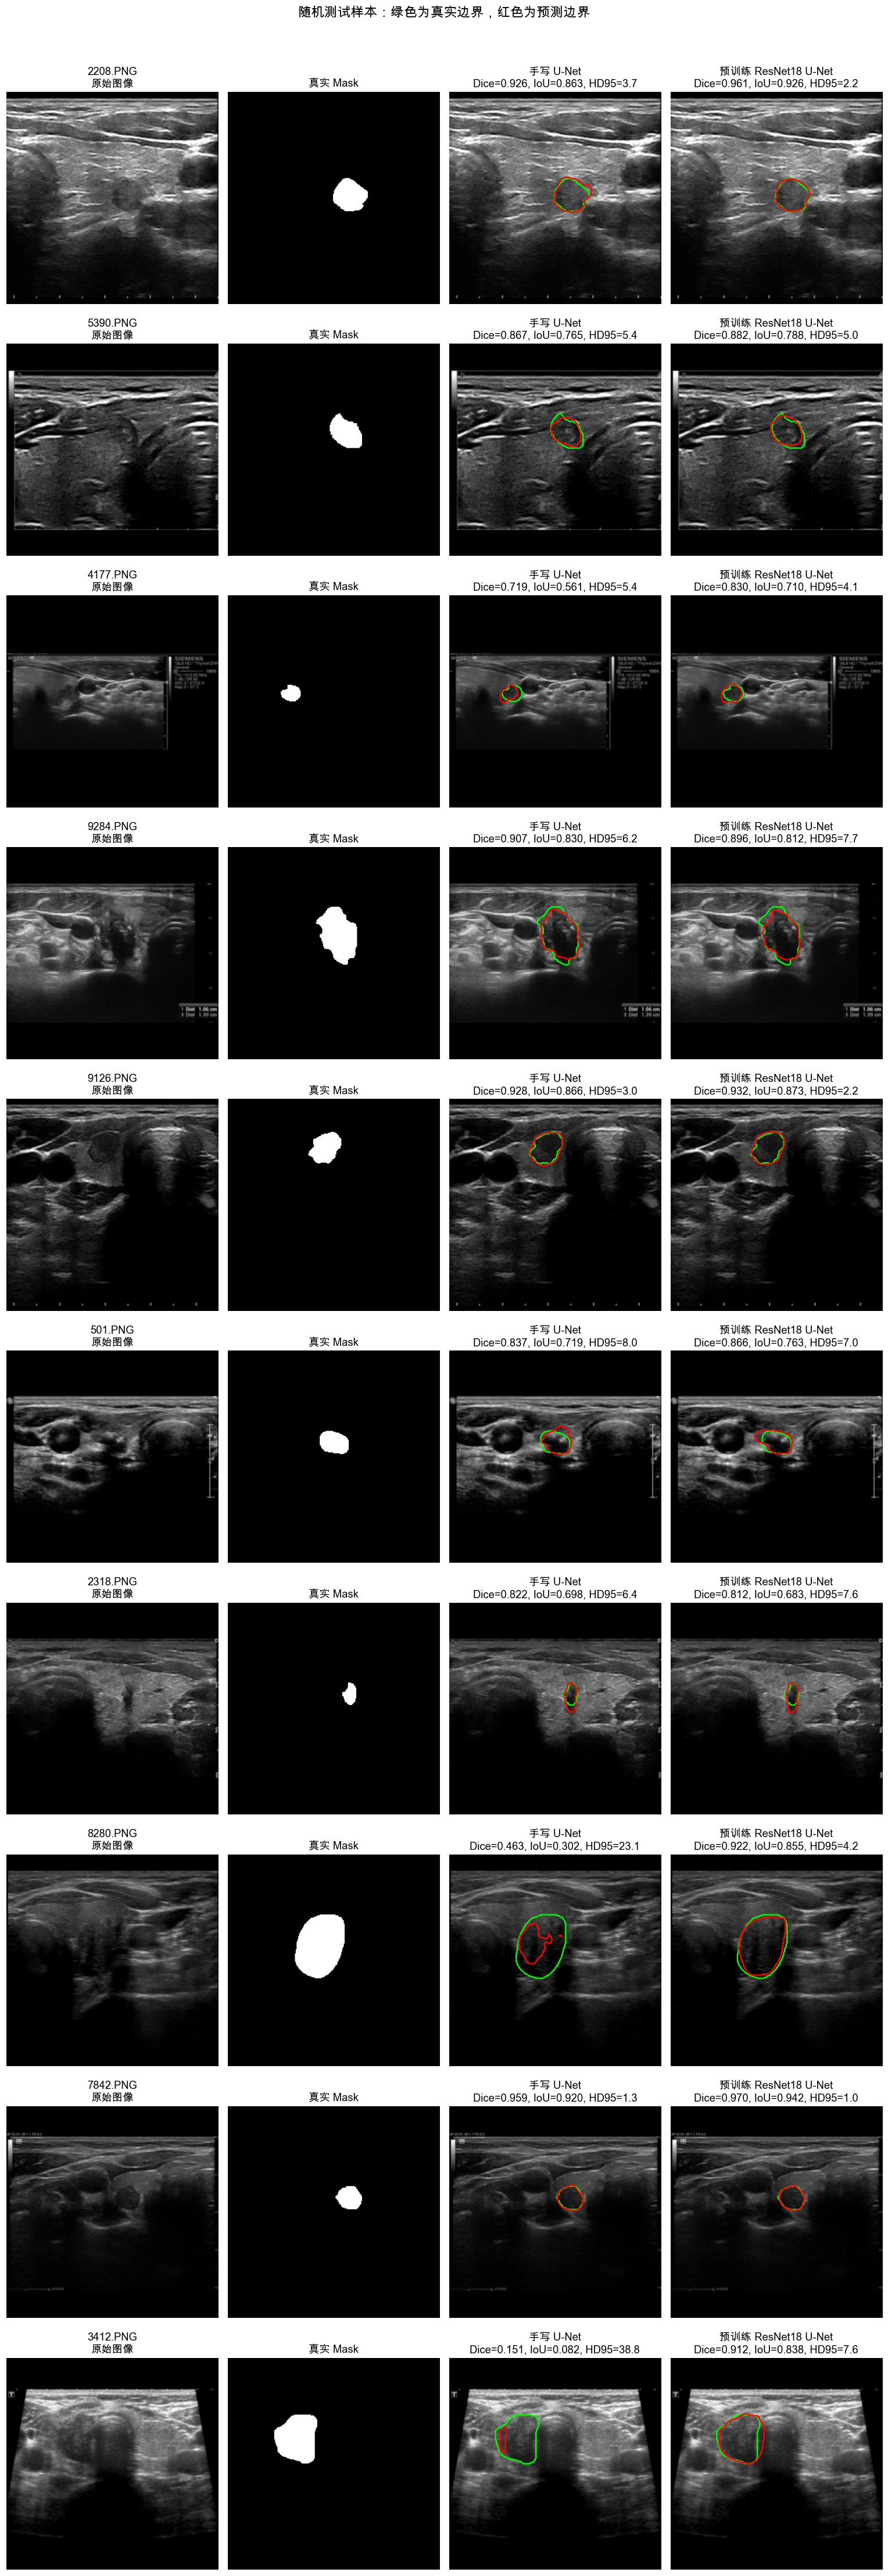

In [10]:
import numpy as np
# 随机显示测试集中的若干张图片
N_SHOW = 10

# 不设置固定种子，所以每次运行都会随机换一批
rng = np.random.default_rng()
random_indices = rng.choice(
    len(test_ids),
    size=min(N_SHOW, len(test_ids)),
    replace=False,
)

fig, axes = plt.subplots(
    len(random_indices),
    4,
    figsize=(14, 4 * len(random_indices)),
    squeeze=False,
)

for row, index in enumerate(random_indices):
    sample_id = test_ids[index]

    image = test_images[index, 0].numpy()
    target = test_targets[index, 0].numpy() >= 0.5

    hand_prediction = (
        hand_probabilities[index, 0].numpy() >= THRESHOLD
    )
    pretrained_prediction = (
        pretrained_probabilities[index, 0].numpy() >= THRESHOLD
    )

    hand_score = hand_cases.loc[
        hand_cases.ID == sample_id
    ].iloc[0]

    pretrained_score = pretrained_cases.loc[
        pretrained_cases.ID == sample_id
    ].iloc[0]

    # 第一列：原始图像
    axes[row, 0].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[row, 0].set_title(f"{sample_id}\n原始图像")

    # 第二列：真实 Mask
    axes[row, 1].imshow(target, cmap="gray", vmin=0, vmax=1)
    axes[row, 1].set_title("真实 Mask")

    # 第三列：手写 U-Net
    axes[row, 2].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[row, 2].contour(
        target.astype(float),
        levels=[0.5],
        colors="lime",
        linewidths=1.5,
    )

    if hand_prediction.any():
        axes[row, 2].contour(
            hand_prediction.astype(float),
            levels=[0.5],
            colors="red",
            linewidths=1.5,
        )

    axes[row, 2].set_title(
        "手写 U-Net\n"
        f"Dice={hand_score.dice:.3f}, "
        f"IoU={hand_score.iou:.3f}, "
        f"HD95={hand_score.hd95_pixels:.1f}"
    )

    # 第四列：预训练 U-Net
    axes[row, 3].imshow(image, cmap="gray", vmin=0, vmax=1)
    axes[row, 3].contour(
        target.astype(float),
        levels=[0.5],
        colors="lime",
        linewidths=1.5,
    )

    if pretrained_prediction.any():
        axes[row, 3].contour(
            pretrained_prediction.astype(float),
            levels=[0.5],
            colors="red",
            linewidths=1.5,
        )

    axes[row, 3].set_title(
        "预训练 ResNet18 U-Net\n"
        f"Dice={pretrained_score.dice:.3f}, "
        f"IoU={pretrained_score.iou:.3f}, "
        f"HD95={pretrained_score.hd95_pixels:.1f}"
    )

    for axis in axes[row]:
        axis.axis("off")

fig.suptitle(
    "随机测试样本：绿色为真实边界，红色为预测边界",
    fontsize=15,
    y=1.01,
)
fig.tight_layout()
plt.show()